# Exploitation de données électorales avec Python

**Évaluation intermédiaire** — *Python pour la data science*  
Données : Élection présidentielle française 2022 — 1er tour

---

## Imports et chargement des données

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from great_tables import GT, md
from cartiflette import carti_download

import utils as u

In [26]:
df = pd.read_csv(
    'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb',
    low_memory=False
)

df.head()
df[df['libelle_commune'] == 'Montrouge']

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
34535,92,Hauts-de-Seine,49,Montrouge,Nathalie,ARTHAUD,96
69780,92,Hauts-de-Seine,49,Montrouge,Fabien,ROUSSEL,499
105025,92,Hauts-de-Seine,49,Montrouge,Emmanuel,MACRON,8291
140270,92,Hauts-de-Seine,49,Montrouge,Jean,LASSALLE,349
175515,92,Hauts-de-Seine,49,Montrouge,Marine,LE PEN,1775
210760,92,Hauts-de-Seine,49,Montrouge,Éric,ZEMMOUR,1466
246005,92,Hauts-de-Seine,49,Montrouge,Jean-Luc,MÉLENCHON,6683
281250,92,Hauts-de-Seine,49,Montrouge,Anne,HIDALGO,508
316495,92,Hauts-de-Seine,49,Montrouge,Yannick,JADOT,1952
351740,92,Hauts-de-Seine,49,Montrouge,Valérie,PÉCRESSE,1468


---

## 1. Explorations générales

### Question 1

Création de deux nouvelles colonnes :
- `code_commune` : code INSEE complet à 5 caractères (département + commune), ex. `92049` pour Montrouge.
- `candidat` : prénom et nom concaténés (abstentions, blancs et nuls conservés).

In [ ]:
# Construction du code commune INSEE (5 caractères)
df['code_commune'] = (
    df['code_departement'].astype(str).str.zfill(2)
    + df['code_commune'].astype(int).astype(str).str.zfill(3)
)


In [ ]:
# Vérification sur Montrouge, Bastia et Espiet
df[df['libelle_commune'].isin(['Bastia', 'Montrouge', 'Espiet'])]

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
6717,2B,Haute-Corse,2B033,Bastia,Nathalie,ARTHAUD,56
12453,33,Gironde,33157,Espiet,Nathalie,ARTHAUD,5
34535,92,Hauts-de-Seine,92049,Montrouge,Nathalie,ARTHAUD,96
41962,2B,Haute-Corse,2B033,Bastia,Fabien,ROUSSEL,495
47698,33,Gironde,33157,Espiet,Fabien,ROUSSEL,7
69780,92,Hauts-de-Seine,92049,Montrouge,Fabien,ROUSSEL,499
77207,2B,Haute-Corse,2B033,Bastia,Emmanuel,MACRON,2173
82943,33,Gironde,33157,Espiet,Emmanuel,MACRON,92
105025,92,Hauts-de-Seine,92049,Montrouge,Emmanuel,MACRON,8291
112452,2B,Haute-Corse,2B033,Bastia,Jean,LASSALLE,974


In [28]:
# Colonne candidat : prénom + nom (NaN remplacé par '' pour les non-exprimés)
df['candidat'] = df['prenom'].fillna('') + ' ' + df['nom'].str.strip()

In [31]:
df[['candidat']].drop_duplicates().reset_index(drop=True)

,candidat
0,Nathalie ARTHAUD
1,Fabien ROUSSEL
2,Emmanuel MACRON
3,Jean LASSALLE
4,Marine LE PEN
5,Éric ZEMMOUR
6,Jean-Luc MÉLENCHON
7,Anne HIDALGO
8,Yannick JADOT
9,Valérie PÉCRESSE


### Question 2

Comptage du nombre de candidats en excluant les votes non exprimés (abstentions, blancs, nuls).

In [32]:
non_exprime = df['nom'].isin(['abstentions', 'blancs', 'nuls'])

candidats = df[~ non_exprime]['candidat'].unique()

print(f"En 2022, il y avait {len(candidats)} candidats à l'élection présidentielle.")

En 2022, il y avait 12 candidats à l'élection présidentielle.


### Question 3

Calcul des scores nationaux pour chaque candidat (votes exprimés uniquement), mis en forme avec `great_tables`.

In [33]:
df_exprimes = df[~non_exprime]

# Agrégation au niveau nationale
scores_nationaux = df_exprimes.groupby('candidat')['voix'].sum().reset_index()
scores_nationaux.columns = ['candidat', 'votes']

scores_nationaux['score'] = scores_nationaux['votes'] / scores_nationaux['votes'].sum() * 100
scores_nationaux = scores_nationaux.sort_values('votes', ascending=False)

scores_nationaux['votes_fmt'] = [u.formater_votes(x) for x in scores_nationaux['votes']]
scores_nationaux['score_fmt'] = [u.formater_score(x) for x in scores_nationaux['score']]

(
    GT(scores_nationaux[['candidat', 'votes_fmt', 'score_fmt']])
    .tab_header(
        title=md("Table 1. – Réponse à la question 3 <br> Elections 🇫🇷"),
        subtitle=md("Résultats du premier tour (📅 10 avril 2022)")
    )
    .cols_label(
        candidat="Candidat",
        votes_fmt="Nombre votes (total)",
        score_fmt="Score (% votes exprimés)"
    )
    .cols_align(align="right", columns=["votes_fmt", "score_fmt"])
)

GT(_tbl_data=                 candidat  votes_fmt score_fmt
1         Emmanuel MACRON  9 783 058    27.85%
5           Marine LE PEN  8 133 828    23.15%
4      Jean-Luc MÉLENCHON  7 712 520    21.95%
11           Éric ZEMMOUR  2 485 226     7.07%
9        Valérie PÉCRESSE  1 679 001     4.78%
10          Yannick JADOT  1 627 853     4.63%
3           Jean LASSALLE  1 101 387     3.13%
2          Fabien ROUSSEL    802 422     2.28%
7   Nicolas DUPONT-AIGNAN    725 176     2.06%
0            Anne HIDALGO    616 478     1.75%
8         Philippe POUTOU    268 904     0.77%
6        Nathalie ARTHAUD    197 094     0.56%, _body=<great_tables._gt_data.Body object at 0x7f5363253770>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='votes_fmt', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='score_fmt', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f5361996060>, _spanners=Spanners([]), _heading=Heading(title=Md(text='Table 1. – Réponse à la question 3 <br> Elections 🇫🇷'), subtitle=Md(text='Résultats du premier tour (📅 10 avril 2022)'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f5362f7ac50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f5354271950>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f53619968b0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, categor

---

## 2. Comparaison des scores départementaux aux moyennes nationales

### Question 4

Création d'un dataframe `score_departements` avec, pour chaque département et chaque candidat, le nombre de votes et le score en %.## Question 4

In [39]:
# Agrégation par département
score_departements = df_exprimes.groupby(['code_departement', 'candidat'])['voix'].sum().reset_index()
score_departements.columns = ['code_departement', 'candidat', 'votes']

total_dep = score_departements.groupby('code_departement')['votes'].sum().reset_index()
total_dep.columns = ['code_departement', 'total']

score_departements = score_departements.merge(total_dep, on='code_departement')
score_departements['score'] = score_departements['votes'] / score_departements['total'] * 100
score_departements = score_departements.drop(columns='total')
score_departements = score_departements.sort_values(['code_departement', 'votes'], ascending=[True, False])

score_departements['score_fmt'] = [u.formater_score(x) for x in score_departements['score']]
score_departements['votes_fmt'] = [u.formater_votes(x) for x in score_departements['votes']]

# Vérification Aude (11)
aude = score_departements[score_departements['code_departement'].astype(str) == '11']


(
    GT(aude[['code_departement', 'candidat', 'votes_fmt', 'score_fmt']])
    .tab_header(
        title=md("**Résultats par département**"),
        subtitle=md("*Département de l'Aude (11)*")
    )
    .cols_label(
        code_departement=md("**code_departement**"),
        candidat=md("**candidat**"),
        votes_fmt=md("**votes**"),
        score_fmt=md("**score**")
    )
    .cols_align(align="right", columns=["code_departement", "votes_fmt", "score_fmt"])
)

GT(_tbl_data=    code_departement               candidat votes_fmt score_fmt
125               11          Marine LE PEN    64 027    30.14%
121               11        Emmanuel MACRON    43 104    20.29%
124               11     Jean-Luc MÉLENCHON    42 039    19.79%
131               11           Éric ZEMMOUR    18 434     8.68%
123               11          Jean LASSALLE    12 382     5.83%
129               11       Valérie PÉCRESSE     7 350     3.46%
130               11          Yannick JADOT     6 322     2.98%
120               11           Anne HIDALGO     6 166     2.90%
122               11         Fabien ROUSSEL     5 622     2.65%
127               11  Nicolas DUPONT-AIGNAN     4 206     1.98%
128               11        Philippe POUTOU     1 748     0.82%
126               11       Nathalie ARTHAUD     1 026     0.48%, _body=<great_tables._gt_data.Body object at 0x7f53544a7150>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='**code_departement**'), column_align='right', column_width=None), ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='**candidat**'), column_align='left', column_width=None), ColInfo(var='votes_fmt', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='**votes**'), column_align='right', column_width=None), ColInfo(var='score_fmt', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='**score**'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f5354272c50>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Résultats par département**'), subtitle=Md(text="*Département de l'Aude (11)*"), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f535aac7f50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f5362f692e0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f5354271c50>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_b

### Question 5

Jointure avec les scores nationaux pour permettre la comparaison département / national.

In [40]:
# Renommage des colonnes départementales
score_departements = score_departements.rename(columns={
    'votes': 'votes_departement',
    'score': 'score_departement',
    'votes_fmt': 'votes_fmt_departement',
    'score_fmt': 'score_fmt_departement'
})

# Fusion avec les données nationales
score_departements = score_departements.merge(
    scores_nationaux[['candidat', 'votes', 'score', 'votes_fmt', 'score_fmt']].rename(columns={
        'votes': 'votes_national',
        'score': 'score_national',
        'votes_fmt': 'votes_fmt_national',
        'score_fmt': 'score_fmt_national'
    }),
    on='candidat'
)

# Vérification Aude (11)
aude = score_departements[score_departements['code_departement'].astype(str) == '11']
aude = aude.sort_values('votes_departement', ascending=False).head(3)


(
    GT(aude[['code_departement', 'candidat', 'votes_fmt_departement', 'score_fmt_departement', 'votes_fmt_national', 'score_fmt_national']])
    .cols_label(
        code_departement=md("**code_departement**"),
        candidat=md("**candidat**"),
        votes_fmt_departement=md("**votes_departement**"),
        score_fmt_departement=md("**score_departement**"),
        votes_fmt_national=md("**votes_national**"),
        score_fmt_national=md("**score_national**")
    )
    .cols_align(align="right", columns=["code_departement", "votes_fmt_departement", "score_fmt_departement", "votes_fmt_national", "score_fmt_national"])
)

code_departement,candidat,votes_departement,score_departement,votes_national,score_national
11,Marine LE PEN,64 027,30.14%,8 133 828,23.15%
11,Emmanuel MACRON,43 104,20.29%,9 783 058,27.85%
11,Jean-Luc MÉLENCHON,42 039,19.79%,7 712 520,21.95%


### Question 6

Calcul de la **surreprésentation** : écart relatif entre le score départemental et le score national.

$$
\text{surreprésentation} = \frac{\text{score\_departement} - \text{score\_national}}{\text{score\_national}} \times 100
$$

Exemple : 30 % dans un département vs 15 % au national → surreprésentation = **100 %**.

In [43]:
score_departements['surrepresentation'] = (
    (score_departements['score_departement'] - score_departements['score_national'])
    / score_departements['score_national']
    * 100
)
score_departements[score_departements['code_departement'].astype(str) == '11'][['candidat', 'surrepresentation']]

,candidat,surrepresentation
120,Marine LE PEN,30.189236
121,Emmanuel MACRON,-27.129818
122,Jean-Luc MÉLENCHON,-9.850571
123,Éric ZEMMOUR,22.676282
124,Jean LASSALLE,85.933551
125,Valérie PÉCRESSE,-27.599212
126,Yannick JADOT,-35.768773
127,Anne HIDALGO,65.421840
128,Fabien ROUSSEL,15.876381
129,Nicolas DUPONT-AIGNAN,-4.074791


### Question 7

Fonction visualisant le **Top N des surreprésentations** (en valeur absolue) par département pour un candidat donné.

In [50]:
def plot_surrepresentation(nom: str, n: int = 5) -> None:
    """Affiche un graphique en barres horizontales des n départements
    avec les plus fortes surreprésentations (en valeur absolue) pour
    le candidat `nom`.

    Paramètres
    ----------
    nom : str
        Nom complet du candidat tel qu'il apparaît dans la colonne 'candidat'.
    n : int
        Nombre de départements à afficher (défaut : 5).
    """
    data = score_departements[score_departements['candidat'] == nom].copy()
    data = (
        data
        .assign(abs_surr=data['surrepresentation'].abs())
        .nlargest(n, 'abs_surr')
        .sort_values('surrepresentation')
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(data['code_departement'].astype(str), data['surrepresentation'])
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Surreprésentation (%)')
    ax.set_ylabel('Département')
    ax.set_title(f"Top {n} des surreprésentations — {nom}")
    fig.tight_layout()
    plt.show()

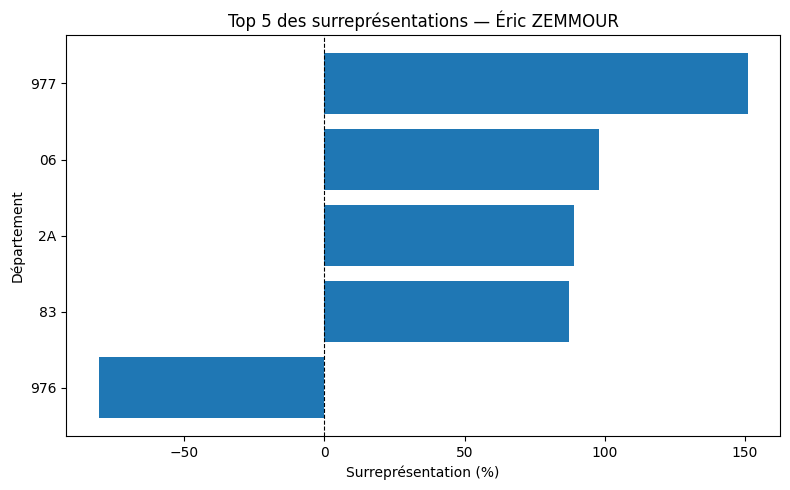

In [51]:
plot_surrepresentation('Éric ZEMMOUR')

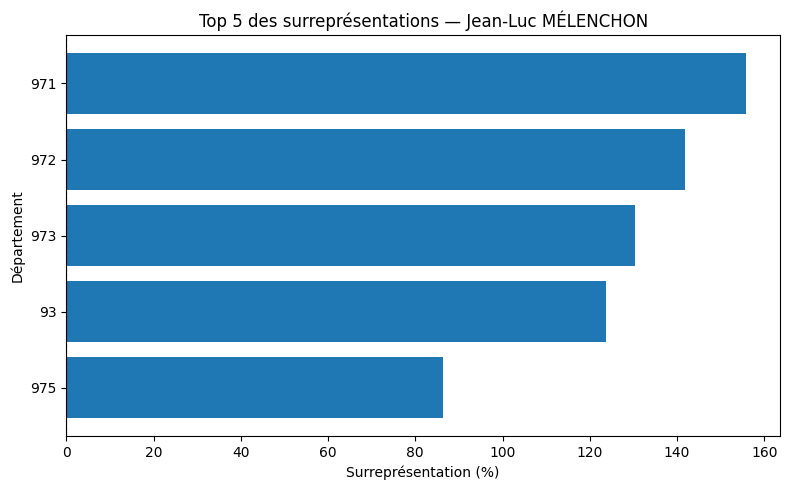

In [52]:
plot_surrepresentation('Jean-Luc MÉLENCHON')

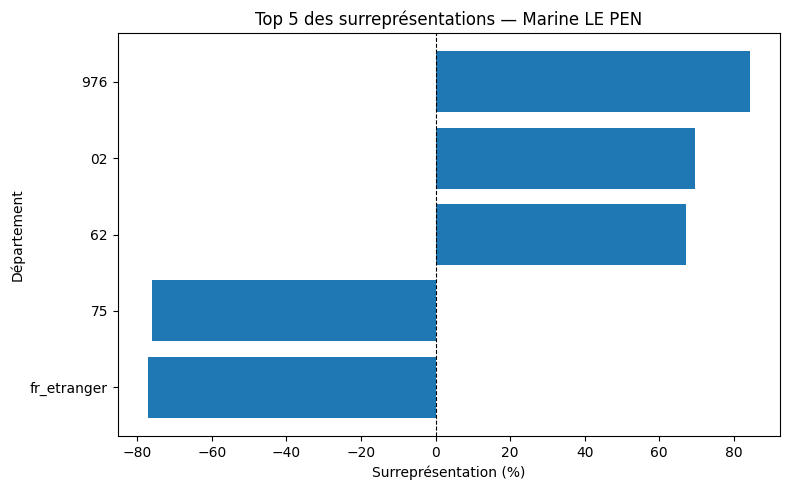

In [53]:
plot_surrepresentation('Marine LE PEN')

---

## 3. Un peu de cartographie

### Question 8

Carte de la surreprésentation départementale pour un candidat donné,
à partir du fond de carte récupéré via `cartiflette`.

In [54]:
# Téléchargement du fond de carte des départements (France entière + DROM rapprochés)
departement_borders = carti_download(
    values=["France"],
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

In [60]:
def carte_surrepresentation(nom: str) -> None:
    """Affiche une carte choroplèthe de la surreprésentation départementale
    pour le candidat `nom`.

    Paramètres
    ----------
    nom : str
        Nom complet du candidat tel qu'il apparaît dans la colonne 'candidat'.
    """
    # Filtrage sur le candidat (sans écraser score_departements)
    data_candidat = score_departements[score_departements['candidat'] == nom].copy()

    # Jointure avec le fond de carte
    gdf = departement_borders.merge(
        data_candidat,
        left_on='INSEE_DEP',
        right_on='code_departement',
        how='left'
    )

    # Échelle symétrique autour de 0
    vmax = gdf['surrepresentation'].abs().max()

    fig, ax = plt.subplots(figsize=(8, 7))
    gdf.plot(
        column='surrepresentation',
        cmap='RdBu_r',
        vmin=-vmax, vmax=vmax,
        edgecolor='white', linewidth=0.4,
        ax=ax,
        legend=True,
        legend_kwds={
            'label': '% par rapport\nmoyenne nationale',
            'orientation': 'vertical'
        }
    )
    ax.set_title(f"Surreprésentation de {nom} au 1er tour\nde l'élection présidentielle 2022", fontsize=13, fontweight='bold')    
    ax.axis('off')
    fig.tight_layout()
    plt.show()

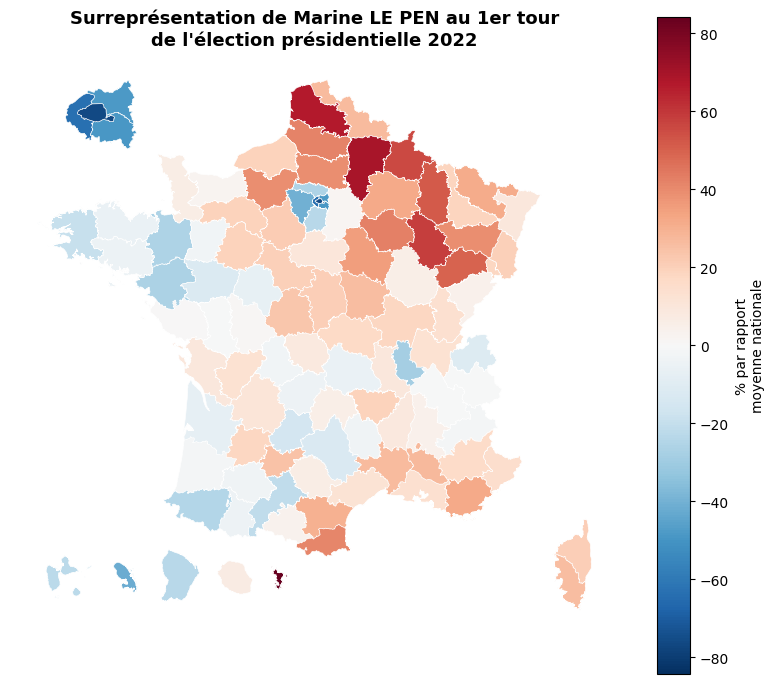

In [61]:
carte_surrepresentation('Marine LE PEN')

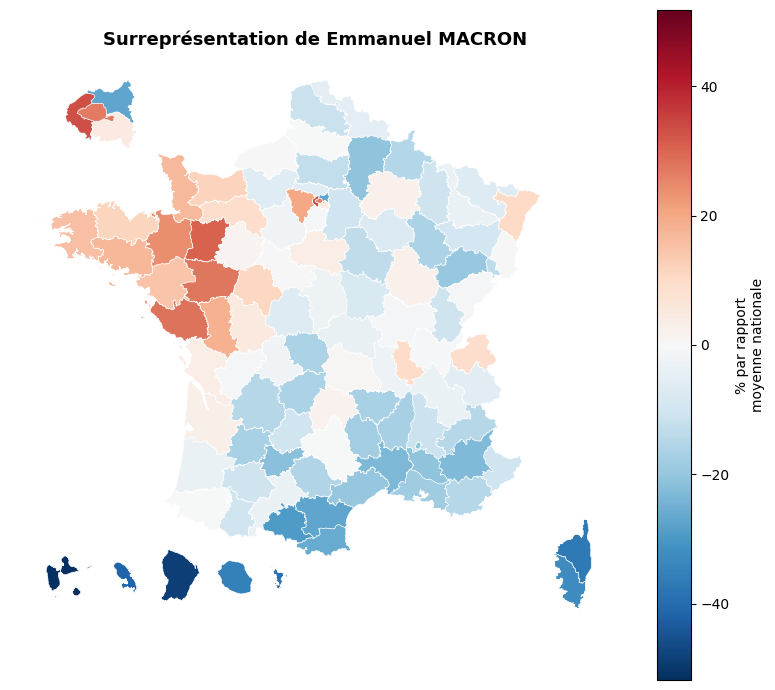

In [57]:
carte_surrepresentation('Emmanuel MACRON')

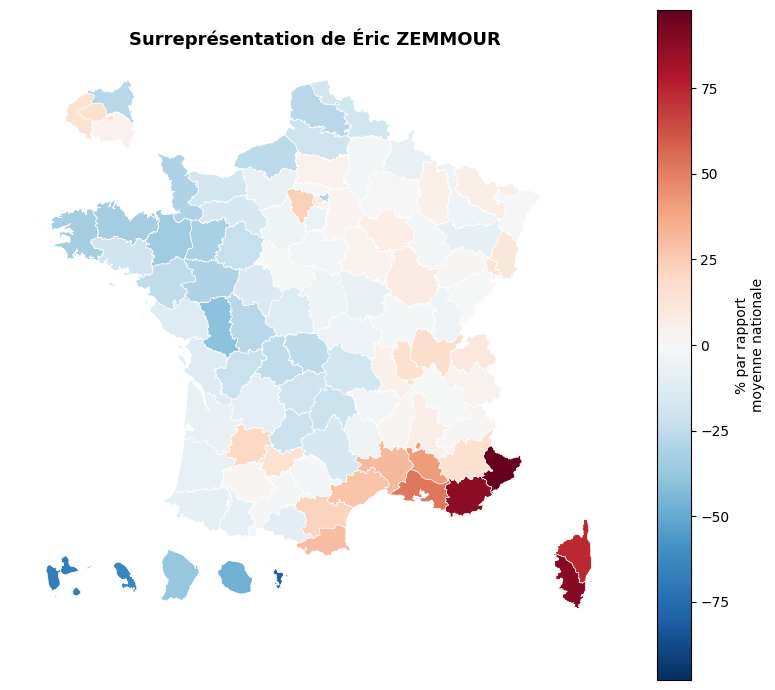

In [58]:
carte_surrepresentation('Éric ZEMMOUR')